In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("customer_churn_dataset-training-master.csv")

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [4]:
df.shape

(440833, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


In [6]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='str')

Categorical Columns:
Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='str')


C:\Users\Hanna J Joseph\AppData\Local\Temp\ipykernel_38772\2041061977.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


In [9]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='str')

In [10]:
df = pd.read_csv("customer_churn_dataset-training-master.csv")

In [11]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [12]:
df.shape

(440833, 12)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


In [14]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='str')

Categorical Columns:
Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='str')


C:\Users\Hanna J Joseph\AppData\Local\Temp\ipykernel_38772\2041061977.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


In [17]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='str')

In [25]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               0
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    0
Contract Length      0
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [31]:
# Fill missing values in numerical columns
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing values in categorical columns
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check if any missing values remain
print(df.isnull().sum())

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [32]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

In [26]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

In [27]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [36]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

In [37]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(random_state=42)

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [39]:
def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return accuracy, precision, recall, f1

In [40]:
log_results = evaluate_model(y_test, log_pred)
tree_results = evaluate_model(y_test, tree_pred)
forest_results = evaluate_model(y_test, forest_pred)

In [42]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        log_results[0],
        tree_results[0],
        forest_results[0]
    ],
    "Precision": [
        log_results[1],
        tree_results[1],
        forest_results[1]
    ],
    "Recall": [
        log_results[2],
        tree_results[2],
        forest_results[2]
    ],
    "F1 Score": [
        log_results[3],
        tree_results[3],
        forest_results[3]
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.978087,0.981594,0.97975,0.980671
1,Decision Tree,0.999705,0.999740,0.99974,0.999740
2,Random Forest,0.999614,0.999520,0.99980,0.999660


In [43]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print(best_model)

Model        Decision Tree
Accuracy          0.999705
Precision          0.99974
Recall             0.99974
F1 Score           0.99974
Name: 1, dtype: object


In [44]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

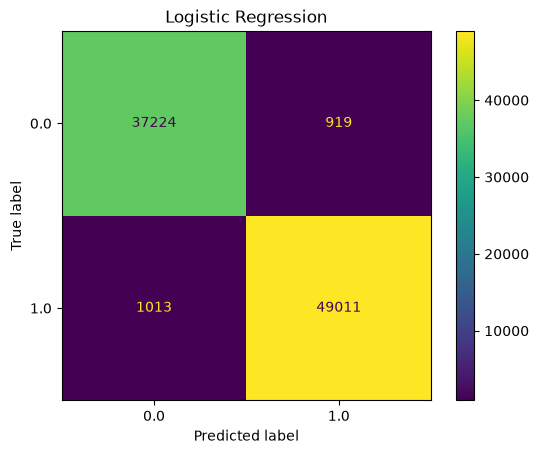

In [45]:
ConfusionMatrixDisplay.from_predictions(y_test, log_pred)
plt.title("Logistic Regression")
plt.show()

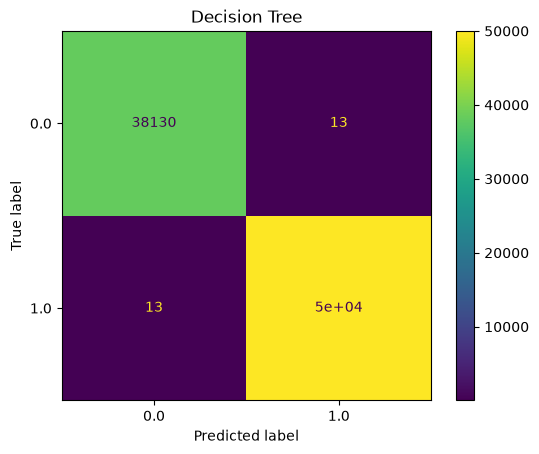

In [46]:
ConfusionMatrixDisplay.from_predictions(y_test, tree_pred)
plt.title("Decision Tree")
plt.show()

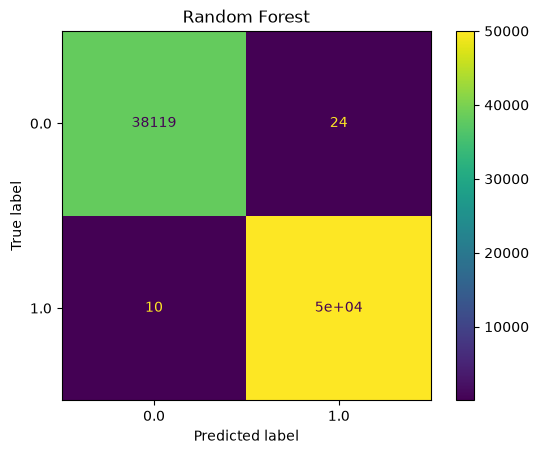

In [47]:
ConfusionMatrixDisplay.from_predictions(y_test, forest_pred)
plt.title("Random Forest")
plt.show()

In [48]:
print("Conclusion")
print("- Logistic Regression performed well with 97.81% accuracy.")
print("- Decision Tree achieved the highest accuracy of 99.97%.")
print("- Random Forest also performed exceptionally with 99.96% accuracy.")
print("- Based on accuracy, Decision Tree is the best model for this dataset.")

Conclusion
- Logistic Regression performed well with 97.81% accuracy.
- Decision Tree achieved the highest accuracy of 99.97%.
- Random Forest also performed exceptionally with 99.96% accuracy.
- Based on accuracy, Decision Tree is the best model for this dataset.


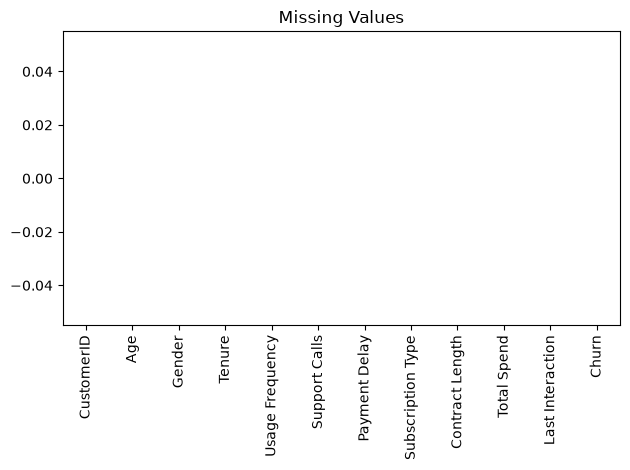

In [50]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()

missing.plot(kind="bar")
plt.title("Missing Values")
plt.tight_layout()
plt.savefig("images/missing_values.png")
plt.show()

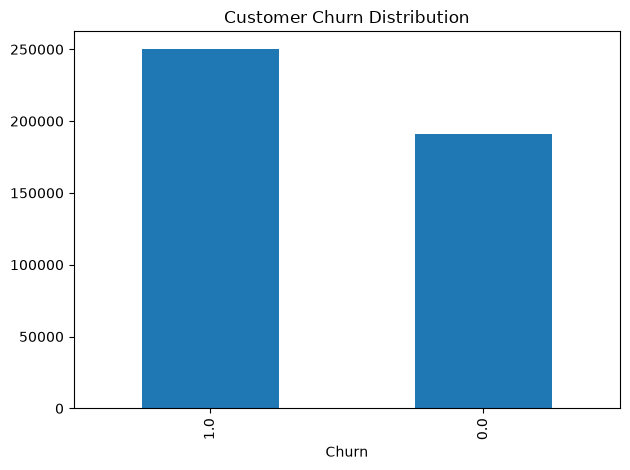

In [51]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.tight_layout()
plt.savefig("images/churn_distribution.png")
plt.show()

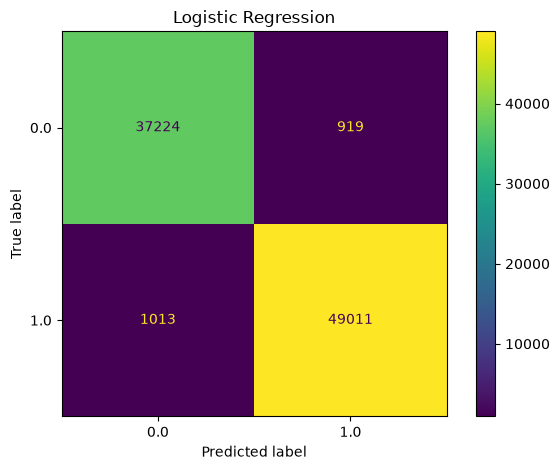

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, log_pred)
plt.title("Logistic Regression")
plt.tight_layout()
plt.savefig("images/logistic_cm.png")
plt.show()

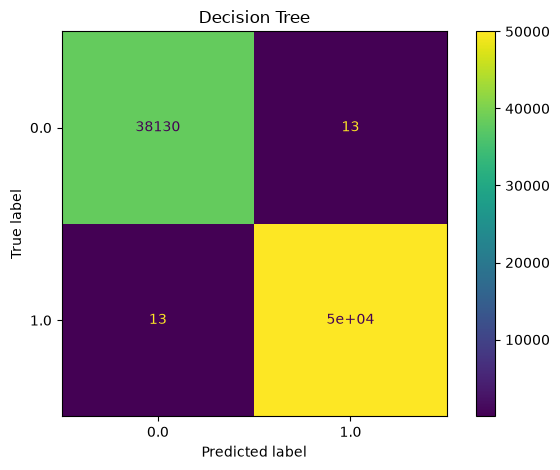

In [53]:
ConfusionMatrixDisplay.from_predictions(y_test, tree_pred)
plt.title("Decision Tree")
plt.tight_layout()
plt.savefig("images/decision_tree_cm.png")
plt.show()

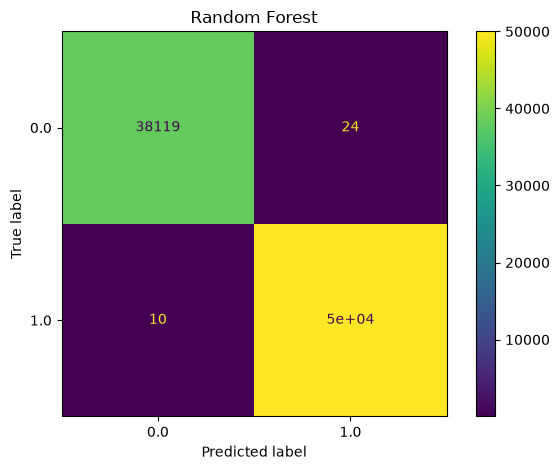

In [54]:
ConfusionMatrixDisplay.from_predictions(y_test, forest_pred)
plt.title("Random Forest")
plt.tight_layout()
plt.savefig("images/random_forest_cm.png")
plt.show()